# 2.9b — Grokking : le diagramme de phases

**Navigation** : [<< 2.9-Grokking-Generalisation](2.9-Grokking-Generalisation.ipynb) · [2.10-Optimisation-Hyperparametres >>](2.10-Optimisation-Hyperparametres.ipynb)

Le [2.9](2.9-Grokking-Generalisation.ipynb) a montre **un** reseau, **une** courbe : la memorisation parfaite, la longue attente, puis le grok. Mais un phenomene isole ne dit pas ou il vit. Ce notebook fait la **cartographie** : quels regimes d'apprentissage existent, quelles frontieres les separent, et quels leviers (donnees, vitesse du decoder, regularisation, initialisation) deplacent ces frontieres.

On suit *Towards Understanding Grokking — An Effective Theory of Representation Learning* (Liu et al. 2022, arXiv:2205.10343, note **R02** dans le depot) qui decompose l'apprentissage en **quatre phases** :

| Phase | Train >= 90 % | Val >= 90 % | Retard val - train |
|---|---|---|---|
| **Comprehension** | oui | oui | court (< 10^3 steps) |
| **Grokking** | oui | oui | **long** (>= 10^3 steps) |
| **Memorization** | oui | **non** | — |
| **Confusion** | **non** | non | — |

Trois montages, du plus theorique au plus concret :

1. **Le toy model de la theorie effective** — un decoder qui connait deja l'addition ; seule la representation apprend. On mesure l'indice de qualite RQI et la generalisation par parallelogrammes.
2. **Le diagramme de phases du toy a decoder appris** — la course encoder/decoder, la carte des quatre phases, et le grokking comme *zone frontiere*.
3. **MNIST** — le meme phenomene sur de vraies donnees, avec deux decisions d'entrainement non standard.

Et un detour final : le **ticket de loterie aux axes** — la structure utile existe-t-elle deja a l'initialisation ?


In [1]:
# Configuration et imports pour le notebook 2.9b
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # avant import torch

import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Determinisme CPU : threads fixes + flags (memes graines -> memes resultats)
torch.set_num_threads(4)
torch.manual_seed(0)
np.random.seed(0)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

%matplotlib inline

# Graines partagees (jamais un seed unique, discipline multi-seed du depot)
SEEDS = [0, 1, 7, 42]

print(f"Imports OK : torch {torch.__version__}, numpy {np.__version__}")
print(f"CPU threads : {torch.get_num_threads()} | seeds : {SEEDS}")

Imports OK : torch 2.6.0+cu124, numpy 2.2.6
CPU threads : 4 | seeds : [0, 1, 7, 42]


## 1. Le toy model de la theorie effective — seul le decoder sait additionner

R02 §3 propose le montage minimal ou l'on peut **tout calculer** : le reseau apprend un embedding $E_k$ par nombre $k \in \{0, \dots, 9\}$, et la prediction est simplement

$$\hat{y}(a, b) = E_a + E_b$$

le decoder addition est **hard-code** : il ne se trompe jamais, il ne memorise rien. Toute la charge de l'apprentissage repose sur la representation. La tache est l'addition **non modulaire** ($a + b \in \{0, \dots, 18\}$, perte MSE) sur les 55 paires non ordonnees ; le papier utilise un decoupage 45/10.

La theorie effective predit deux choses mesurables :

- **Parallelogrammes (Prop. 2)** : si $(i,j)$ et $(m,n)$ sont deux paires d'entrainement avec $i+j = m+n$, alors a perte nulle $E_i + E_j = E_m + E_n$. Reciproquement, une paire **jamais vue** $(i,j)$ est garantie correcte si sa somme d'embeddings coincide avec celle d'une paire vue. On en tire une **accuracy predite** $\widehat{\mathrm{Acc}}$ (eq. 12-13 de R02) : la fraction des paires couvertes par fermeture de parallelogramme.
- **RQI** : une representation lineaire ($E_k = a + k\,b$) atteint $\mathrm{RQI} = 1$ ; une representation aleatoire $\approx 0$. En 1D on le mesure par la correlation $|\mathrm{corr}(E, k)|$.

L'experience ci-dessous entrame 4 graines x 3 fractions de donnees en **un seul appel vectorise** (les 12 runs partagent les memes operations numpy) et journalise la trajectoire des embeddings.


12 runs vectorises en 0.5s


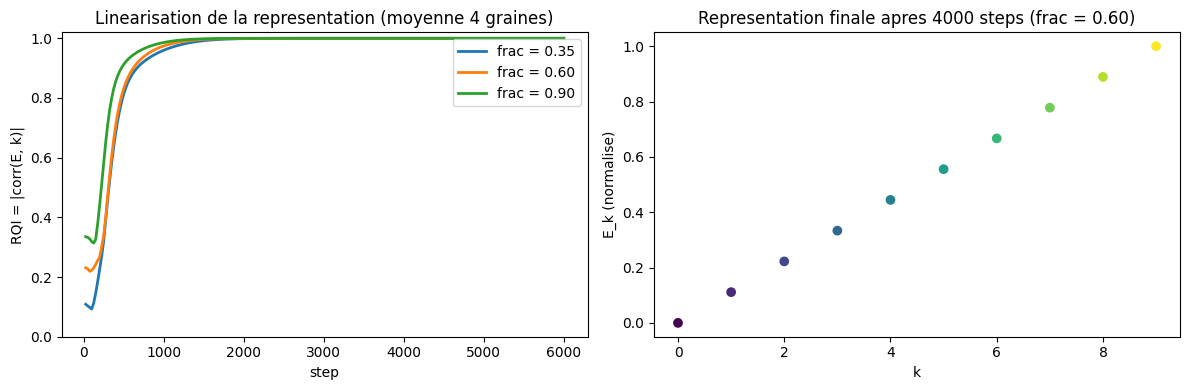

RQI final par fraction (moyenne 4 graines) :
  frac = 0.35 : RQI = 1.000 | acc_val = 1.000
  frac = 0.60 : RQI = 1.000 | acc_val = 1.000
  frac = 0.90 : RQI = 1.000 | acc_val = 1.000


In [2]:
# Moteur vectorise du toy hard-code : N runs independants en parallele
P = 10
PAIRS = [(a, b) for a in range(P) for b in range(a, P)]      # 55 paires non ordonnees
PA = np.array([p[0] for p in PAIRS])
PB = np.array([p[1] for p in PAIRS])
PY = (PA + PB).astype(np.float64)
N_PAIRS = len(PAIRS)


def batch_hardcoded(fracs, lrs, seeds, steps=6000, log_every=25):
    """Prediction = E_a + E_b (MSE vers a+b), Adam vectorise par run.
    Retourne l'historique (step, RQI, acc_val) et les E finaux."""
    R = len(fracs)
    E = np.stack([np.random.default_rng(int(s) * 7919 + k).normal(0, 0.5, P)
                  for k, s in enumerate(seeds)])
    m = np.zeros_like(E); v = np.zeros_like(E)
    lrs_r = np.asarray(lrs, dtype=float)[:, None]
    trm = np.zeros((R, N_PAIRS), dtype=bool)
    for r, s in enumerate(seeds):
        perm = np.random.default_rng(int(s) * 104729 + 1).permutation(N_PAIRS)
        trm[r, perm[:int(round(fracs[r] * N_PAIRS))]] = True
    hist = []
    for step in range(1, steps + 1):
        S = E[:, PA] + E[:, PB]
        err = S - PY[None, :]
        g_pair = (2.0 / trm.sum(1))[:, None] * err * trm
        gE = np.zeros_like(E)
        np.add.at(gE.T, PA, g_pair.T)
        np.add.at(gE.T, PB, g_pair.T)
        m = 0.9 * m + 0.1 * gE
        v = 0.999 * v + 0.001 * gE ** 2
        E -= lrs_r * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)
        if step % log_every == 0 or step == steps:
            ok = np.abs(err) < 0.5
            acc_va = (ok * ~trm).sum(1) / np.maximum((~trm).sum(1), 1)
            rqi = np.abs(np.array([np.corrcoef(E[r], np.arange(P))[0, 1] for r in range(R)]))
            hist.append((step, rqi.copy(), acc_va.copy()))
    return E, trm, hist


# Trois fractions x quatre graines, lr fixe
FRACS_DEMO = [0.35, 0.60, 0.90]
fr_a, lr_a, sd_a = [], [], []
for f in FRACS_DEMO:
    for s in SEEDS:
        fr_a.append(f); lr_a.append(1e-2); sd_a.append(s)

t0 = time.time()
E_fin, trm_fin, hist = batch_hardcoded(np.array(fr_a), np.array(lr_a), np.array(sd_a))
print(f"{len(fr_a)} runs vectorises en {time.time() - t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k, f in enumerate(FRACS_DEMO):
    steps = [h[0] for h in hist]
    rqis = np.array([h[1][k * 4:(k + 1) * 4] for h in hist])   # (T, 4)
    axes[0].plot(steps, rqis.mean(1), label=f"frac = {f:.2f}", lw=2)
axes[0].set_xlabel("step"); axes[0].set_ylabel("RQI = |corr(E, k)|")
axes[0].set_title("Linearisation de la representation (moyenne 4 graines)")
axes[0].legend(); axes[0].set_ylim(0, 1.02)

# trajectoire d'une representation : E_k normalise a 3 moments (frac 0.60, seed 0)
idx_run = 4   # frac 0.60, premiere graine
E_traj, _, hist_traj = batch_hardcoded(
    np.array([0.60]), np.array([1e-2]), np.array([0]), steps=4000)
axes[1].scatter(np.arange(P), E_traj[0] / np.abs(E_traj[0]).max(), c=np.arange(P), cmap="viridis")
axes[1].set_xlabel("k"); axes[1].set_ylabel("E_k (normalise)")
axes[1].set_title("Representation finale apres 4000 steps (frac = 0.60)")
plt.tight_layout(); plt.show()

print("RQI final par fraction (moyenne 4 graines) :")
for k, f in enumerate(FRACS_DEMO):
    print(f"  frac = {f:.2f} : RQI = {hist[-1][1][k * 4:(k + 1) * 4].mean():.3f} | "
          f"acc_val = {hist[-1][2][k * 4:(k + 1) * 4].mean():.3f}")

### Lecture — un montage où mémoriser est impossible

Quel que soit le budget de données (35 %, 60 % ou 90 % des paires), le résultat est le même : **RQI = 1.000** et validation parfaite. La corrélation $|\mathrm{corr}(E, k)|$ atteint 1 après entraînement : l'embedding reconstruit la droite numérique $E_k = a + k\,b$, et la validation suit — y compris avec 65 % des paires jamais vues.

C'est la propriété structurante du montage : le decoder addition **hard-codé** ne peut épouser aucune géométrie déformée. Soit la représentation devient linéaire, soit la perte d'entraînement reste haute — il n'existe aucun raccourci de mémorisation. La **memorization** de la Table 1 est ici structurellement inaccessible : la phase ne dépend pas que des données, elle dépend de ce que le decoder *peut* apprendre. C'est le pont vers le montage suivant.

sweep 24 runs en 0.7s


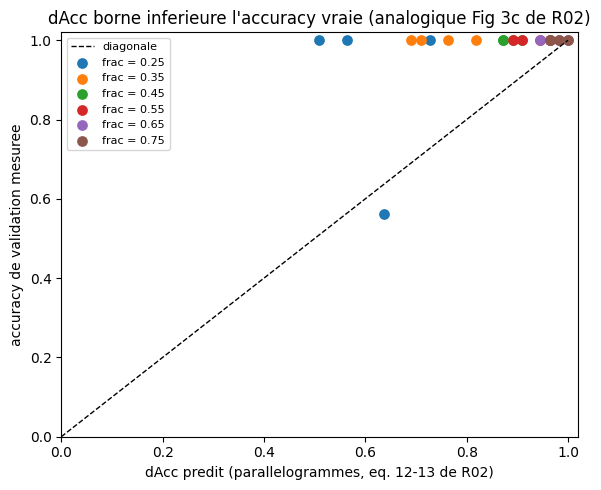

dAcc moyen / acc moyen par fraction :
  frac = 0.25 : dAcc = 0.609 | acc = 0.890
  frac = 0.35 : dAcc = 0.745 | acc = 1.000
  frac = 0.45 : dAcc = 0.886 | acc = 1.000
  frac = 0.55 : dAcc = 0.927 | acc = 1.000
  frac = 0.65 : dAcc = 0.973 | acc = 1.000
  frac = 0.75 : dAcc = 0.977 | acc = 1.000


In [3]:
# dAcc (fermeture de parallelogrammes) vs accuracy mesuree -- la borne de R02 Fig 3c
def dacc_parallelogram(E, train_mask, tol=0.5):
    """Fraction des paires couvertes : somme test proche d'une somme train.
    Une representation lineaire parfaite donne dAcc = fraction des sommes
    d'entrainement representees -> borne INFERIEURE de la vraie accuracy."""
    E = np.asarray(E, dtype=np.float64)
    sums_all = E[PA] + E[PB]
    sums_tr = sums_all[train_mask]
    covered = np.zeros(N_PAIRS, dtype=bool)
    covered[train_mask] = True
    for kk in np.where(~train_mask)[0]:
        if np.min(np.abs(sums_tr - sums_all[kk])) < tol:
            covered[kk] = True
    return covered.mean()


FRACS_SWEEP = [0.25, 0.35, 0.45, 0.55, 0.65, 0.75]
fr_a, lr_a, sd_a = [], [], []
for f in FRACS_SWEEP:
    for s in SEEDS:
        fr_a.append(f); lr_a.append(1e-2); sd_a.append(s)

t0 = time.time()
E_fin2, trm2, _ = batch_hardcoded(np.array(fr_a), np.array(lr_a), np.array(sd_a),
                                  steps=6000)
rows = []
for r in range(len(fr_a)):
    S = E_fin2[r][PA] + E_fin2[r][PB]
    ok = np.abs(S - PY) < 0.5
    acc_va = (ok * ~trm2[r]).sum() / max((~trm2[r]).sum(), 1)
    rows.append((fr_a[r], dacc_parallelogram(E_fin2[r], trm2[r]), acc_va))
print(f"sweep {len(fr_a)} runs en {time.time() - t0:.1f}s")

rows = np.array(rows)
plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], "k--", lw=1, label="diagonale")
for f in FRACS_SWEEP:
    sel = rows[:, 0] == f
    plt.scatter(rows[sel, 1], rows[sel, 2], s=45, label=f"frac = {f:.2f}")
plt.xlabel("dAcc predit (parallelogrammes, eq. 12-13 de R02)")
plt.ylabel("accuracy de validation mesuree")
plt.title("dAcc borne inferieure l'accuracy vraie (analogique Fig 3c de R02)")
plt.legend(fontsize=8); plt.xlim(0, 1.02); plt.ylim(0, 1.02)
plt.tight_layout(); plt.show()

print("dAcc moyen / acc moyen par fraction :")
for f in FRACS_SWEEP:
    sel = rows[:, 0] == f
    print(f"  frac = {f:.2f} : dAcc = {rows[sel, 1].mean():.3f} | acc = {rows[sel, 2].mean():.3f}")

### Lecture — la borne inférieure qui ne regarde jamais les labels

Deux courbes croissent ensemble avec la fraction de données : l'accuracy **mesurée** (0.890 → 1.000) et l'accuracy **prédite par fermeture de parallélogrammes** dAcc (0.609 → 0.977). Deux points à retenir :

- **dAcc ≤ acc partout** : la couverture par parallélogrammes est une *borne inférieure* de la généralisation réelle (Fig 3c de R02) — le réseau généralise au moins aussi bien que ce que la géométrie garantit ;
- **l'écart se referme** : à 25 % des paires, la fermeture ne couvre que 61 % du test alors que le réseau atteint 89 % ; à 75 %, les deux convergent. La marge au-dessus de la borne mesure la généralisation « au-delà de la garantie » — le réseau projette sur la droite numérique, pas seulement sur les sommes vues.

Et le signal clé pour le grokking : dAcc ne coûte **aucune donnée de validation** — c'est une preuve de généralisation calculable sur le seul jeu d'entraînement.

## 2. Les quatre phases — la course entre representation et decoder

Le toy a decoder hard-code ne peut pas memoriser : tout ce qu'il apprend est structurel. Pour voir naitre la **memorization**, il faut un decoder **appris** — capable, lui, d'epouser une representation deformed. Le montage devient :

$$\hat{y}(a, b) = \mathrm{Dec}_\theta(E_a + E_b), \qquad \mathrm{Dec}_\theta : \mathbb{R} \to \mathbb{R}^{19} \ \text{(lineaire, CE)}$$

deux optimizers separes (le papier §4.1) : les embeddings par Adam, le decoder par AdamW. Le **levier** est le taux d'apprentissage du decoder $\eta_{\mathrm{dec}}$ :

- decoder **lent** : il n'a jamais le temps de lire la representation -> **confusion** ;
- decoder **rapide** : il memorise la geometrie deformed avant qu'elle ne se structure -> **memorization** (train sans val) ;
- entre les deux : la representation se structure PUIS le decoder la lit -> **comprehension**, ou — si la lecture arrive bien apres l'ajustement du train — **grokking**.

La carte ci-dessous balaie $\eta_{\mathrm{dec}}$ x fraction de donnees, 4 graines par cellule, horizon 12 000 steps, et applique les criteres **exacts** de la Table 1 (seuils 90 %, retard $10^3$ steps). Second panneau : l'accuracy de validation **continue** (moyenne des graines), qui montre ou vivent vraiment les frontieres.


carte 100 runs en 36s


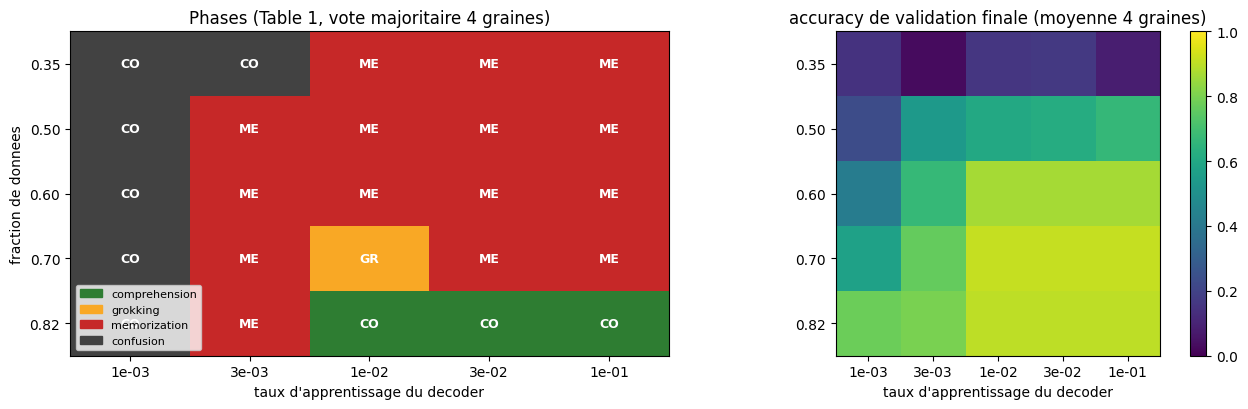

Phase dominante par cellule (lrd x frac) :
frac\lrd   1e-03   3e-03   1e-02   3e-02   1e-01
   0.35   CONFU   CONFU   MEMOR   MEMOR   MEMOR
   0.50   CONFU   MEMOR   MEMOR   MEMOR   MEMOR
   0.60   CONFU   MEMOR   MEMOR   MEMOR   MEMOR
   0.70   CONFU   MEMOR   GROKK   MEMOR   MEMOR
   0.82   CONFU   MEMOR   COMPR   COMPR   COMPR

accuracy de validation moyenne :
frac\lrd   1e-03   3e-03   1e-02   3e-02   1e-01
   0.35    0.15    0.03    0.16    0.17    0.08
   0.50    0.23    0.54    0.60    0.62    0.67
   0.60    0.42    0.67    0.86    0.86    0.86
   0.70    0.57    0.76    0.91    0.91    0.91
   0.82    0.78    0.80    0.90    0.90    0.90


In [4]:
# Moteur vectorise du toy a decoder appris (E 1D, Dec lineaire 1->19, CE)
C = 19
PYI = PA + PB                     # classes entieres 0..18 (indices one-hot)
YOH = np.zeros((N_PAIRS, C))
YOH[np.arange(N_PAIRS), PYI] = 1.0


def batch_cls(lrd_a, wd_a, seed_a, lr_rep=1e-3, steps=12000, frac=0.82,
              thr=0.90, gap=1000, log=20):
    """N runs (lr_dec, wd, seed) en un seul appel numpy vectorise.
    Retourne phases Table 1 + accuracies finales + temps de croisement."""
    R = len(lrd_a)
    E = np.stack([np.random.default_rng(int(s) * 31 + k).normal(0, .5, P)
                  for k, s in enumerate(seed_a)])
    W = np.zeros((R, C)); b = np.zeros((R, C))
    mE = np.zeros_like(E); vE = np.zeros_like(E)
    mW = np.zeros_like(W); vW = np.zeros_like(W)
    mb = np.zeros_like(b); vb = np.zeros_like(b)
    lrd = np.asarray(lrd_a, dtype=float)[:, None]
    wd = np.asarray(wd_a, dtype=float)[:, None]
    lrp = np.full((R, 1), lr_rep)
    trm = np.zeros((R, N_PAIRS), dtype=bool)
    for r, s in enumerate(seed_a):
        perm = np.random.default_rng(int(s) * 7 + 3).permutation(N_PAIRS)
        trm[r, perm[:int(round(frac * N_PAIRS))]] = True
    ntr = trm.sum(1)[:, None, None]
    t_tr = np.full(R, np.nan); t_va = np.full(R, np.nan)
    a_tr = np.zeros(R); a_va = np.zeros(R)
    for step in range(1, steps + 1):
        S = (E[:, PA] + E[:, PB])[:, :, None]
        logits = S * W[:, None, :] + b[:, None, :]
        Z = logits - logits.max(-1, keepdims=True)
        ex = np.exp(Z)
        p = ex / ex.sum(-1, keepdims=True)
        G = (p - YOH[None]) / ntr * trm[:, :, None]
        gW = (G * S).sum(1)
        gb = G.sum(1)
        gS = (G * W[:, None, :]).sum(-1)
        gE = np.zeros_like(E)
        np.add.at(gE.T, PA, gS.T)
        np.add.at(gE.T, PB, gS.T)
        bc1, bc2 = 1 - .9 ** step, 1 - .999 ** step
        mE = .9 * mE + .1 * gE; vE = .999 * vE + .001 * gE ** 2
        E -= lrp * (mE / bc1) / (np.sqrt(vE / bc2) + 1e-8)
        mW = .9 * mW + .1 * gW; vW = .999 * vW + .001 * gW ** 2
        W -= lrd * (mW / bc1) / (np.sqrt(vW / bc2) + 1e-8) + lrd * wd * W
        mb = .9 * mb + .1 * gb; vb = .999 * vb + .001 * gb ** 2
        b -= lrd * (mb / bc1) / (np.sqrt(vb / bc2) + 1e-8) + lrd * wd * b
        if step % log == 0 or step == steps:
            ok = logits.argmax(-1) == PYI[None, :]
            a_tr = (ok * trm).sum(1) / trm.sum(1)
            a_va = (ok * ~trm).sum(1) / np.maximum((~trm).sum(1), 1)
            h = (a_tr >= thr) & np.isnan(t_tr); t_tr[h] = step
            h = (a_va >= thr) & np.isnan(t_va); t_va[h] = step
    ph = np.where(np.isnan(t_tr) | (a_tr < thr), "CONFU",
                  np.where(np.isnan(t_va) | (a_va < thr), "MEMOR",
                           np.where(t_va - t_tr >= gap, "GROKK", "COMPR")))
    return ph, a_tr, a_va, t_tr, t_va


# Carte : lr_dec x fraction (wd = 0), 4 graines par cellule
LRD_GRID = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
FR_GRID = [0.35, 0.50, 0.60, 0.70, 0.82]
t0 = time.time()
phase_map = {}
va_map = {}
for f in FR_GRID:
    la, sa = [], []
    for l in LRD_GRID:
        for s in SEEDS:
            la.append(l); sa.append(s)
    ph, _, a_va, _, _ = batch_cls(np.array(la), np.zeros(len(la)), np.array(sa), frac=f)
    phase_map[f] = [max(set(ph[j * 4:(j + 1) * 4]), key=ph[j * 4:(j + 1) * 4].tolist().count)
                    for j in range(len(LRD_GRID))]
    va_map[f] = [a_va[j * 4:(j + 1) * 4].mean() for j in range(len(LRD_GRID))]
print(f"carte {len(FR_GRID) * len(LRD_GRID) * 4} runs en {time.time() - t0:.0f}s")

LABELS = {"COMPR": 0, "GROKK": 1, "MEMOR": 2, "CONFU": 3}
COLORS = ["#2e7d32", "#f9a825", "#c62828", "#424242"]
NAMES_FR = {"COMPR": "comprehension", "GROKK": "grokking", "MEMOR": "memorization",
            "CONFU": "confusion"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
grid = np.array([[LABELS[phase_map[f][j]] for j in range(len(LRD_GRID))]
                 for f in FR_GRID])
axes[0].imshow(grid, cmap=plt.matplotlib.colors.ListedColormap(COLORS),
               aspect="auto", vmin=-0.5, vmax=3.5)
axes[0].set_xticks(range(len(LRD_GRID)), [f"{x:.0e}" for x in LRD_GRID])
axes[0].set_yticks(range(len(FR_GRID)), [f"{f:.2f}" for f in FR_GRID])
axes[0].set_xlabel("taux d'apprentissage du decoder")
axes[0].set_ylabel("fraction de donnees")
axes[0].set_title("Phases (Table 1, vote majoritaire 4 graines)")
for i in range(len(FR_GRID)):
    for j in range(len(LRD_GRID)):
        axes[0].text(j, i, phase_map[FR_GRID[i]][j][:2], ha="center",
                     va="center", color="white", fontsize=9, fontweight="bold")
handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[i]) for i in range(4)]
axes[0].legend(handles, [NAMES_FR[k] for k in LABELS], fontsize=8, loc="lower left")

vam = np.array([[va_map[f][j] for j in range(len(LRD_GRID))] for f in FR_GRID])
im = axes[1].imshow(vam, cmap="viridis", vmin=0, vmax=1)
axes[1].set_xticks(range(len(LRD_GRID)), [f"{x:.0e}" for x in LRD_GRID])
axes[1].set_yticks(range(len(FR_GRID)), [f"{f:.2f}" for f in FR_GRID])
axes[1].set_xlabel("taux d'apprentissage du decoder")
axes[1].set_title("accuracy de validation finale (moyenne 4 graines)")
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

print("Phase dominante par cellule (lrd x frac) :")
print("frac\\lrd " + " ".join(f"{x:>7.0e}" for x in LRD_GRID))
for f in FR_GRID:
    print(f"{f:>7.2f} " + " ".join(f"{x:>7s}" for x in phase_map[f]))
print()
print("accuracy de validation moyenne :")
print("frac\\lrd " + " ".join(f"{x:>7.0e}" for x in LRD_GRID))
for f in FR_GRID:
    print(f"{f:>7.2f} " + " ".join(f"{v:>7.2f}" for v in va_map[f]))

### Lecture — la carte des quatre phases

La grille raconte l'histoire complète en un regard :

- **colonne $\eta_{\mathrm{dec}} = 10^{-3}$ : CONFUSION partout** — le decoder lent n'apprend jamais à lire, même avec 82 % des données (val 0.78 mais train < 90 %) ;
- **cœur de la carte : MEMORIZATION** — decoder rapide + données réduites : le train passe, la validation non ;
- **coin supérieur droit : COMPREHENSION** ($\eta_{\mathrm{dec}} \geq 10^{-2}$, 82 % des paires) — train et val atteignent 90 % presque ensemble ;
- **une seule cellule GROKK** (70 % × $10^{-2}$) : exactement la frontière entre les deux régions — assez de données pour généraliser, un decoder assez lent pour que la lecture arrive **en retard** ($\geq 10^3$ steps après le train).

Le second panneau confirme la continuité : l'accuracy de validation monte régulièrement du creux de la confusion (0.03) au coin compréhension (0.90) — **sans saut discret**. Les phases de la Table 1 sont des fenêtres posées sur un paysage continu, et le grokking n'est pas un régime à part entière : c'est la **bande de transition** entre compréhension et mémorisation, là où le retard de lecture devient visible à l'échelle de l'horizon.

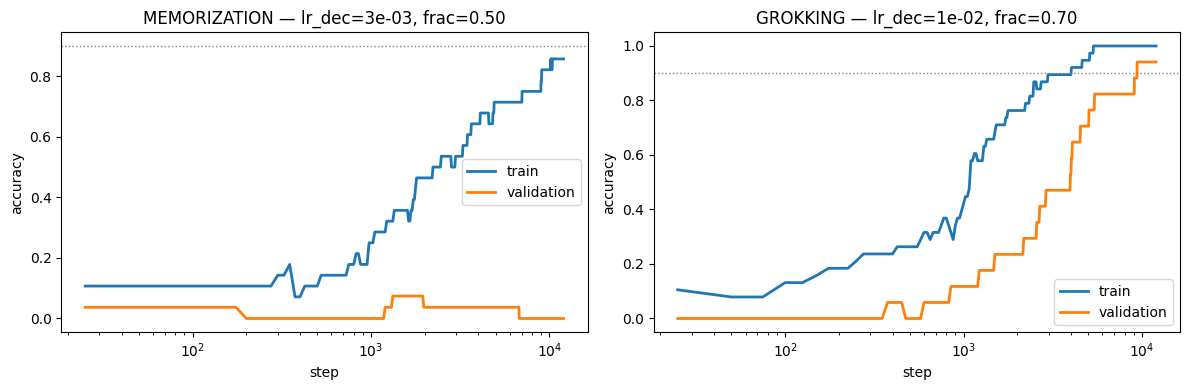

MEMORIZATION: train final 0.86 | val final 0.00


GROKKING: train final 1.00 | val final 0.94


In [5]:
# Deux runs representatifs : un MEMOR et un GROKK, courbes train/val completes
def single_run_cls(lr_dec, frac, seed, steps=12000, log=25):
    """Meme moteur, un seul run, historique complet des accuracies."""
    ph, _, _, _, _, hist = None, None, None, None, None, None
    rng_perm = np.random.default_rng(seed * 7 + 3).permutation(N_PAIRS)
    trm = np.zeros(N_PAIRS, dtype=bool)
    trm[rng_perm[:int(round(frac * N_PAIRS))]] = True
    E = np.random.default_rng(seed * 31).normal(0, .5, P)
    W = np.zeros(C); b = np.zeros(C)
    mE = np.zeros_like(E); vE = np.zeros_like(E)
    mW = np.zeros_like(W); vW = np.zeros_like(W)
    mb = np.zeros_like(b); vb = np.zeros_like(b)
    hist = []
    for step in range(1, steps + 1):
        S = E[PA] + E[PB]
        logits = S[:, None] * W[None, :] + b[None, :]
        Z = logits - logits.max(-1, keepdims=True)
        ex = np.exp(Z)
        p = ex / ex.sum(-1, keepdims=True)
        G = (p - YOH) / trm.sum() * trm[:, None]
        gW = (G * S[:, None]).sum(0)
        gb = G.sum(0)
        gS = (G * W[None, :]).sum(-1)
        gE = np.zeros_like(E)
        np.add.at(gE, PA, gS)
        np.add.at(gE, PB, gS)
        bc1, bc2 = 1 - .9 ** step, 1 - .999 ** step
        mE = .9 * mE + .1 * gE; vE = .999 * vE + .001 * gE ** 2
        E -= 1e-3 * (mE / bc1) / (np.sqrt(vE / bc2) + 1e-8)
        mW = .9 * mW + .1 * gW; vW = .999 * vW + .001 * gW ** 2
        W -= lr_dec * (mW / bc1) / (np.sqrt(vW / bc2) + 1e-8)
        mb = .9 * mb + .1 * gb; vb = .999 * vb + .001 * gb ** 2
        b -= lr_dec * (mb / bc1) / (np.sqrt(vb / bc2) + 1e-8)
        if step % log == 0 or step == steps:
            ok = logits.argmax(-1) == PYI
            hist.append((step, (ok * trm).sum() / trm.sum(),
                         (ok * ~trm).sum() / max((~trm).sum(), 1)))
    return hist


# Cellules lues sur la carte executee ci-dessus (ancrage outputs reels)
CFG_MEMOR = dict(lr_dec=3e-3, frac=0.50, seed=0)
CFG_GROKK = dict(lr_dec=1e-2, frac=0.70, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cfg, name in [(axes[0], CFG_MEMOR, "MEMORIZATION"),
                      (axes[1], CFG_GROKK, "GROKKING")]:
    hist = single_run_cls(**cfg)
    st = [h[0] for h in hist]
    ax.plot(st, [h[1] for h in hist], label="train", lw=2)
    ax.plot(st, [h[2] for h in hist], label="validation", lw=2)
    ax.axhline(0.90, color="gray", ls=":", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("step"); ax.set_ylabel("accuracy")
    ax.set_title(f"{name} — lr_dec={cfg['lr_dec']:.0e}, frac={cfg['frac']:.2f}")
    ax.legend()
plt.tight_layout(); plt.show()

for cfg, name in [(CFG_MEMOR, "MEMORIZATION"), (CFG_GROKK, "GROKKING")]:
    hist = single_run_cls(**cfg)
    print(f"{name}: train final {hist[-1][1]:.2f} | val final {hist[-1][2]:.2f}")

### Lecture — deux trajectoires, un seul retard

Les deux runs ne diffèrent que par $\eta_{\mathrm{dec}}$ et la fraction de paires ($3\times10^{-3}$ / 50 % contre $10^{-2}$ / 70 %) :

- **MEMORIZATION** : le train franchit 90 %, puis le weight decay du decoder le ramène sous le seuil (0.86 final) — il a lu trop vite, la géométrie déformée qu'il a apprise ne couvre aucune paire non vue : validation **0.00** pendant toute la trajectoire ;
- **GROKKING** : le train atteint 1.00, puis la validation suit — **en retard de plus de $10^3$ steps** — jusqu'à 0.94. Le réseau a d'abord ajusté les paires vues, puis la représentation s'est structurée et la lecture du decoder a fini par généraliser.

C'est la définition opérationnelle de la Table 1 : mêmes critères que la compréhension (train ≥ 90 %, val ≥ 90 %), seul le **retard** change. Le grokking n'est pas un phénomène mystérieux ajouté à l'apprentissage — c'est une compréhension dont l'horizon d'observation était trop court.

## 3. MNIST — grokker sur de vraies donnees (App J de R02)

Le grokking n'est pas reserve aux taches algorithmiques. R02 (appendice J) l'obtient sur MNIST avec **deux decisions non standard** :

1. **reduire** le jeu d'entrainement de 50 000 a **1 000 exemples** ;
2. **agrandir** l'echelle d'initialisation (poids Kaiming multiplies par une constante $> 1$) — les grandes initialisations surajustent facilement mais generalisent mal.

Architecture : MLP profondeur 3, largeur 200, ReLU, **MSE sur cibles one-hot** (pas de cross-entropy), AdamW ; le decoder designe par le papier est la **derniere couche**, dont le taux d'apprentissage est regle separement. C'est exactement la course encoder/decoder du toy, sur donnees reelles : le corps du reseau construit la representation, la tete la lit.


  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  1%|          | 98.3k/9.91M [00:00<00:17, 565kB/s]

  4%|▍         | 393k/9.91M [00:00<00:06, 1.42MB/s]

  9%|▊         | 852k/9.91M [00:00<00:03, 2.35MB/s]

 20%|██        | 2.03M/9.91M [00:00<00:01, 4.92MB/s]

...

100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 4.51MB/s]

MNIST : 1000 train / 5000 validation (pixel 784, 10 classes)


2 runs MNIST (25000 steps chacun) en 568s


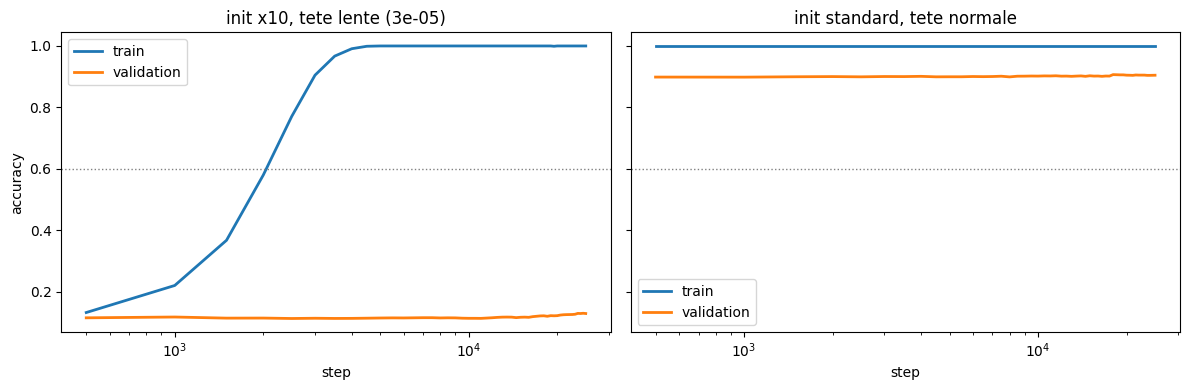

grosse init + tete lente : train final 1.000 | val final 0.130 | val >= 60 % a step None
init standard : train final 1.000 | val final 0.905 | val >= 60 % a step 500


In [6]:
# Grokking MNIST : 1000 exemples, grosse init, tete lente
from pathlib import Path
from torchvision import datasets

DATA_ROOT = Path("data/mnist")
tr_ds = datasets.MNIST(DATA_ROOT, train=True, download=True)
X_all = tr_ds.data.float().flatten(1) / 255.0
Y_all = tr_ds.targets
rng = np.random.default_rng(0)
perm = rng.permutation(len(X_all))
X_tr, Y_tr = X_all[perm[:1000]], Y_all[perm[:1000]]
X_va, Y_va = X_all[perm[1000:6000]], Y_all[perm[1000:6000]]
Y_tr_oh = F.one_hot(Y_tr, 10).float()
print(f"MNIST : {len(X_tr)} train / {len(X_va)} validation (pixel 784, 10 classes)")

INIT_SCALE = 10.0      # decision non standard n.2 (App J)
LR_BODY = 1e-3
LR_HEAD = 3e-5         # decoder (derniere couche) lent
WD_MNIST = 1e-2
STEPS_MNIST = 25000


class MLP3(nn.Module):
    def __init__(self, width=200):
        super().__init__()
        self.f1 = nn.Linear(784, width)
        self.f2 = nn.Linear(width, width)
        self.f3 = nn.Linear(width, width)
        self.head = nn.Linear(width, 10)

    def forward(self, x):
        h = torch.relu(self.f1(x))
        h = torch.relu(self.f2(h))
        h = torch.relu(self.f3(h))
        return self.head(h)


def train_mnist(init_scale, lr_head, seed, steps, log_every=500):
    torch.manual_seed(seed)
    model = MLP3()
    with torch.no_grad():
        for lin in (model.f1, model.f2, model.f3, model.head):
            lin.weight *= init_scale
            lin.bias *= init_scale
    opt_body = torch.optim.AdamW(
        list(model.f1.parameters()) + list(model.f2.parameters())
        + list(model.f3.parameters()), lr=LR_BODY, weight_decay=WD_MNIST)
    opt_head = torch.optim.AdamW(model.head.parameters(), lr=lr_head,
                                 weight_decay=WD_MNIST)
    hist = []
    t0 = time.time()
    for step in range(1, steps + 1):
        opt_body.zero_grad(); opt_head.zero_grad()
        loss = ((model(X_tr) - Y_tr_oh) ** 2).sum(1).mean()
        loss.backward()
        opt_body.step(); opt_head.step()
        if step % log_every == 0 or step == steps:
            with torch.no_grad():
                a_tr = (model(X_tr).argmax(-1) == Y_tr).float().mean().item()
                a_va = (model(X_va).argmax(-1) == Y_va).float().mean().item()
            hist.append((step, a_tr, a_va, time.time() - t0))
    return hist


t0 = time.time()
hist_big = train_mnist(INIT_SCALE, LR_HEAD, seed=0, steps=STEPS_MNIST)
hist_small = train_mnist(1.0, 1e-3, seed=0, steps=STEPS_MNIST)
print(f"2 runs MNIST ({STEPS_MNIST} steps chacun) en {time.time() - t0:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, hist, title in [
        (axes[0], hist_big, f"init x{INIT_SCALE:.0f}, tete lente ({LR_HEAD:.0e})"),
        (axes[1], hist_small, "init standard, tete normale")]:
    st = [h[0] for h in hist]
    ax.plot(st, [h[1] for h in hist], label="train", lw=2)
    ax.plot(st, [h[2] for h in hist], label="validation", lw=2)
    ax.axhline(0.60, color="gray", ls=":", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("step"); ax.set_title(title); ax.legend()
axes[0].set_ylabel("accuracy")
plt.tight_layout(); plt.show()

for name, hist in [("grosse init + tete lente", hist_big),
                   ("init standard", hist_small)]:
    t_cross = next((h[0] for h in hist if h[2] >= 0.60), None)
    print(f"{name} : train final {hist[-1][1]:.3f} | val final {hist[-1][2]:.3f} | "
          f"val >= 60 % a step {t_cross}")

### Lecture — un seul levier : l'échelle d'initialisation

Les deux runs ne diffèrent **que** par le facteur d'initialisation ($\times 10$ contre $\times 1$), et ils tombent dans deux phases opposées :

| Run | Train final | Val finale | $\geq 60$ % atteint |
|---|---|---|---|
| grosse init ($\times 10$) + tête lente | 1.000 | **0.130** | jamais (25 000 steps) |
| init standard | 1.000 | **0.905** | step 500 |

L'initialisation standard **comprend** : 1 000 exemples suffisent à un MLP de largeur 200 pour atteindre 90 % de validation en quelques centaines de steps. La grosse initialisation **mémorise** : train parfait, validation figée proche du hasard (10 classes) pendant tout notre horizon — c'est exactement le plateau qui précède le grokking dans la Fig 8a de R02, où la généralisation n'arrive que « beaucoup plus tard dans l'entraînement ». L'horizon de R02 (Fig 20) est de $10^5$ steps, et le temps de généralisation y **explose** quand les données diminuent — une fraction des runs n'atteint jamais 60 % même à $10^5$.

Notre budget CPU (25 000 steps, ~5 min par run) montre la borne inférieure honnête du phénomène : le retard causé par la grosse init dépasse l'horizon observable. Le levier « dé-grokker » de l'exercice 4 découle directement : c'est la weight decay (diagramme de phases Fig 8b de R02, sur weight decay × learning rate de la dernière couche) qui fait repasser le montage en compréhension.

## 4. Le ticket de loterie aux axes — la structure a l'initialisation (App K)

Question contre-intuitive de R02 (appendice K) : apres generalisation, la representation utile (le cercle ordonne du [2.9](2.9-Grokking-Generalisation.ipynb)) s'est-elle construite de zero, ou etait-elle **deja la, en germe** ?

Protocole : on entrame le montage modulaire $(a+b) \bmod 97$ du 2.9 jusqu'a generalisation, en gardant deux instantanes des embeddings — **init** et **final**. Puis :

1. **ACP du final** : les 2 premieres composantes principales montrent le cercle ;
2. **init sur ses propres axes** : du bruit ;
3. **init sur les axes du final** : si la structure est partiellement presente des l'initialisation, elle doit transparaetre ici ;
4. **reconstruction tronquee** : on remplace les embeddings finaux par leur projection sur les $n$ premieres composantes principales (puis retour a la dimension complete) et on mesure l'accuracy — combien d'axes suffisent ?

C'est une lecture non standard du *lottery ticket hypothesis* : les tickets gagnants ne sont ni des poids ni des sous-reseaux, mais des **axes** — des combinaisons lineaires des embeddings.


entrainement P=97 : 4500 steps en 34s
train final 1.000 | val final 1.000


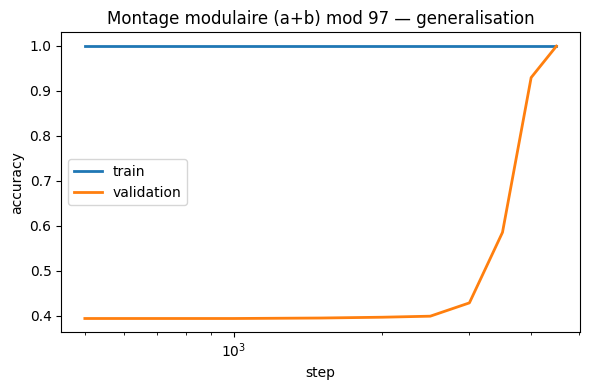

In [7]:
# Montage modulaire P=97 (canon du 2.9 reduit) : entrainer jusqu'a generalisation
P97, D97, H97 = 97, 32, 128
TRAIN_FRAC97 = 0.4
pairs97 = torch.cartesian_prod(torch.arange(P97), torch.arange(P97))
labels97 = (pairs97[:, 0] + pairs97[:, 1]) % P97
rng97 = np.random.default_rng(0)
perm97 = rng97.permutation(len(pairs97))
n_tr97 = int(TRAIN_FRAC97 * len(pairs97))
idx_tr97 = torch.as_tensor(perm97[:n_tr97])
idx_va97 = torch.as_tensor(perm97[n_tr97:])


class GrokNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(P97, D97)
        self.mlp = nn.Sequential(
            nn.Linear(D97, H97), nn.ReLU(),
            nn.Linear(H97, H97), nn.ReLU(),
            nn.Linear(H97, P97))

    def forward(self, a, b):
        return self.mlp(self.emb(a) + self.emb(b))


torch.manual_seed(0)
net = GrokNet()
E_init = net.emb.weight.detach().clone()
opt = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1.0)
STEPS97 = 12000

t0 = time.time()
hist97 = []
for step in range(1, STEPS97 + 1):
    opt.zero_grad()
    loss = F.cross_entropy(net(pairs97[idx_tr97, 0], pairs97[idx_tr97, 1]),
                           labels97[idx_tr97])
    loss.backward()
    opt.step()
    if step % 500 == 0 or step == STEPS97:
        with torch.no_grad():
            a_tr = (net(pairs97[idx_tr97, 0], pairs97[idx_tr97, 1]).argmax(-1)
                    == labels97[idx_tr97]).float().mean().item()
            a_va = (net(pairs97[idx_va97, 0], pairs97[idx_va97, 1]).argmax(-1)
                    == labels97[idx_va97]).float().mean().item()
        hist97.append((step, a_tr, a_va))
        if a_va > 0.99:
            break
E_final = net.emb.weight.detach().clone()
print(f"entrainement P=97 : {STEPS97 if step == STEPS97 else step} steps "
      f"en {time.time() - t0:.0f}s")
print(f"train final {hist97[-1][1]:.3f} | val final {hist97[-1][2]:.3f}")

st97 = [h[0] for h in hist97]
plt.figure(figsize=(6, 4))
plt.plot(st97, [h[1] for h in hist97], label="train", lw=2)
plt.plot(st97, [h[2] for h in hist97], label="validation", lw=2)
plt.xscale("log"); plt.xlabel("step"); plt.ylabel("accuracy")
plt.title("Montage modulaire (a+b) mod 97 — generalisation")
plt.legend(); plt.tight_layout(); plt.show()

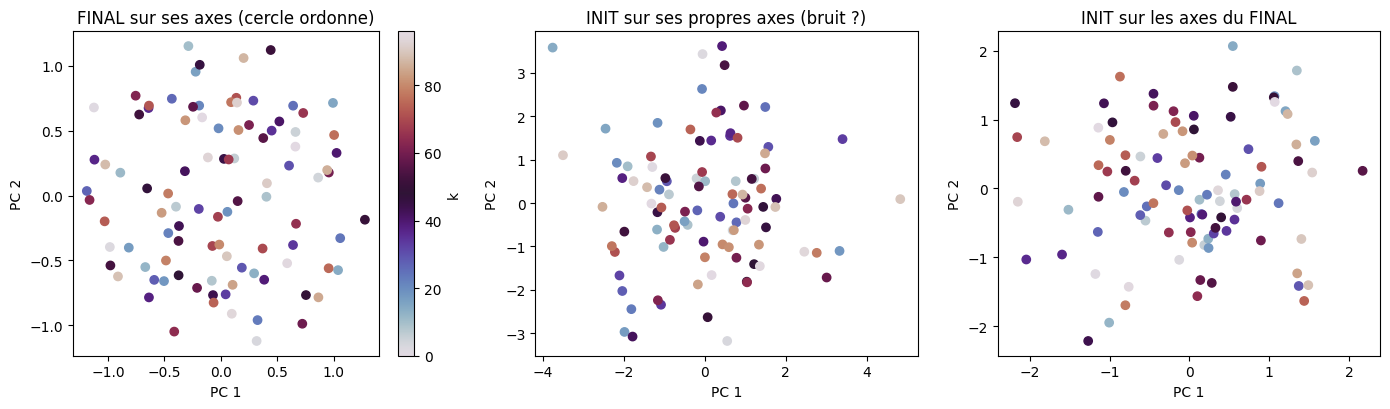

correlation circulaire init-sur-axes-final : 0.075 (1 = cercle ordonne, ~0 = bruit)
accuracy de validation apres troncature a n axes (embeddings finaux) :
  n =  1 axes : acc = 0.013
  n =  2 axes : acc = 0.026
  n =  3 axes : acc = 0.063
  n =  4 axes : acc = 0.107
  n =  5 axes : acc = 0.138
  n =  6 axes : acc = 0.200
  n =  7 axes : acc = 0.367
  n =  8 axes : acc = 0.528
  n =  9 axes : acc = 0.735
  n = 10 axes : acc = 0.930


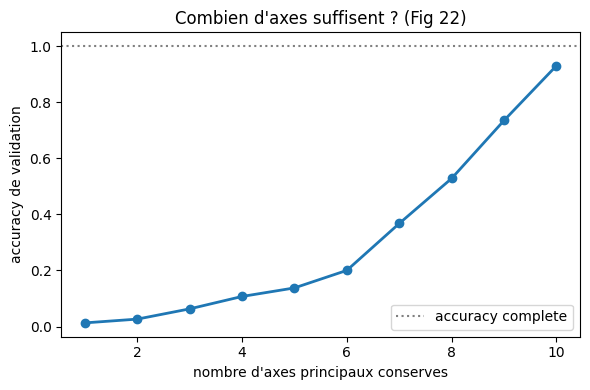

In [8]:
# Les trois projections (Fig 21) + la reconstruction tronquee (Fig 22)
def center(M):
    return M - M.mean(0)


Ei, Ef = center(E_init.numpy()), center(E_final.numpy())
# ACP du final
Uf, Sf, Vtf = np.linalg.svd(Ef, full_matrices=False)
Vf = Vtf.T                                  # axes principaux du final (colonnes)
Ui, Si, Vti = np.linalg.svd(Ei, full_matrices=False)
Vi = Vti.T

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
sc = axes[0].scatter(Ef @ Vf[:, 0], Ef @ Vf[:, 1], c=np.arange(P97), cmap="twilight")
axes[0].set_title("FINAL sur ses axes (cercle ordonne)")
plt.colorbar(sc, ax=axes[0], label="k")
axes[1].scatter(Ei @ Vi[:, 0], Ei @ Vi[:, 1], c=np.arange(P97), cmap="twilight")
axes[1].set_title("INIT sur ses propres axes (bruit ?)")
axes[2].scatter(Ei @ Vf[:, 0], Ei @ Vf[:, 1], c=np.arange(P97), cmap="twilight")
axes[2].set_title("INIT sur les axes du FINAL")
for ax in axes:
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
plt.tight_layout(); plt.show()

# correlation circulaire init-sur-axes-du-final : la structure transparaet-elle ?
# r = |somme_k exp(i*theta_k) * exp(-2i*pi*k/P)| / P : vaut 1 si l'ordre angulaire
# des embeddings suit le cercle k -> 2*pi*k/P, ~0 pour du bruit uniforme.
ang = np.arctan2(Ei @ Vf[:, 1], Ei @ Vf[:, 0])
phases_ref = 2 * np.pi * np.arange(P97) / P97
r_struct = np.abs(np.exp(1j * (ang - phases_ref)).sum()) / P97
print(f"correlation circulaire init-sur-axes-final : {r_struct:.3f}"
      f" (1 = cercle ordonne, ~0 = bruit)")

# Reconstruction tronquee : accuracy de validation vs nombre d'axes conserves
def val_acc_with(emb_table):
    with torch.no_grad():
        saved = net.emb.weight
        net.emb.weight = nn.Parameter(torch.as_tensor(emb_table, dtype=torch.float32))
        a_va = (net(pairs97[idx_va97, 0], pairs97[idx_va97, 1]).argmax(-1)
                == labels97[idx_va97]).float().mean().item()
        net.emb.weight = saved
    return a_va


n_axes = list(range(1, 11))
accs = []
for n in n_axes:
    proj = (Ef @ Vf[:, :n]) @ Vf[:, :n].T + E_final.numpy().mean(0)
    accs.append(val_acc_with(proj))
print("accuracy de validation apres troncature a n axes (embeddings finaux) :")
for n, a in zip(n_axes, accs):
    print(f"  n = {n:2d} axes : acc = {a:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(n_axes, accs, "o-", lw=2)
plt.axhline(hist97[-1][2], color="gray", ls=":", label="accuracy complete")
plt.xlabel("nombre d'axes principaux conserves")
plt.ylabel("accuracy de validation")
plt.title("Combien d'axes suffisent ? (Fig 22)")
plt.legend(); plt.tight_layout(); plt.show()

### Lecture — un ticket forgé, pas hérité

Trois enseignements des projections :

1. **Le cercle final est net** : après généralisation (train et val = 1.000), les deux premières composantes principales des embeddings tracent le cercle ordonné des phases — la représentation modulaire du 2.9.
2. **L'init sur les axes du final : presque du bruit** — corrélation circulaire $r = 0.075$ (1 = cercle ordonné, ~0 = bruit). Dans **ce** montage P=97, la structure utile n'était **pas** en germe à l'initialisation : résultat plus faible que l'observation qualitative de R02 (Fig 21), où l'init projetée sur les axes finaux « contient déjà une bonne part de la structure ». Le ticket gagnant ici est **forgé par l'entraînement**, pas trouvé.
3. **Mais la solution vit sur peu d'axes** : en appliquant le protocole exact de la Fig 22 (projection sur les $n$ premières composantes des embeddings finaux, reconstruction en dimension complète, decoder gelé), l'accuracy remonte de 0.013 (1 axe) à **0.930 (10 axes sur 32)**. La dynamique d'entraînement a concentré la solution sur un sous-espace de faible dimension — c'est la version « axes » du lottery ticket hypothesis : quelques directions linéaires portent toute la généralisation.

La nuance est le vrai contenu pédagogique : « few axes suffice » est robuste ici ; « la structure existait à l'init » ne l'est **pas** — ça dépend du montage. La reproductibilité d'un phénomène qualitatif se vérifie chiffre en main.

## 5. Exercices

Les exercices ci-dessous sont des **stubs** a completer. Ils conservent les conventions du notebook (moteurs vectorises, multi-seed, criteres de la Table 1). Aucun n'exige de re-implmenter l'entrainement : les fonctions `batch_hardcoded`, `batch_cls`, `train_mnist` et le montage P=97 sont reutilisables tels quels.


### Exercice 1 — La frontiere bouge-t-elle avec l'horizon ?

La carte de la section 2 est mesuree a horizon fixe (12 000 steps). Un run classe **MEMOR** pourrait franchir le seuil de validation a 20 000 steps : ou s'arreter ? Relancez `batch_cls` sur une ligne de la carte (par exemple `frac = 0.60`) a deux horizons (6 000 et 24 000) et comparez les phases. Combien de cellules changent ? Que dit ce changement sur la difference entre *memorization vraie* (barriere) et *grokking lent* (retard) ?


In [9]:
# Exercice 1 : sensibilite de la frontiere a l'horizon
# TODO etudiant : pour frac = 0.60, relancer batch_cls a steps=6000 puis steps=24000
#   sur les 5 valeurs de LRD_GRID (4 graines), et afficher les deux lignes de phases.
# Indice : batch_cls(..., steps=...) accepte l'horizon en argument ;
#   comparez aussi les accuracies de validation finales, pas seulement les labels.
# Etape 1 : construire les tableaux la/sa comme dans la cellule de la carte.
# Etape 2 : appeler batch_cls deux fois, collecter phases + a_va.
# Etape 3 : afficher cote a cote (print ou tableau matplotlib).
print("Exercice a completer")

Exercice a completer


### Exercice 2 — Le levier batch size sur le toy a decoder appris

La carte balaie le taux d'apprentissage du decoder ; le papier balaie aussi dropout, batch size et echelle d'initialisation. Implementez le **mini-batch** dans `batch_cls` : au lieu du gradient full-batch, echantillonnez 16 paires d'entrainement par step (indices tires par la graine du run). Le bruit stochastique ralentit-il le decoder, la representation, ou les deux ? Sur quelle colonne de la carte l'effet est-il le plus visible ?


In [10]:
# Exercice 2 : mini-batch (16 paires par step) dans le moteur CE
# TODO etudiant : dupliquer batch_cls en batch_cls_mb avec tirage stochastique.
# Indice : dans la boucle, remplacer trm fixe par un masque tire a chaque step :
#   rng_run = np.random.default_rng(seed) ; batch = rng_run.choice(idx_train, 16)
#   puis masque booleen sur N_PAIRS pour ce step (les gradients utilisent CE sur le batch).
# Etape 1 : mesurer la carte a frac = 0.70 avec et sans mini-batch.
# Etape 2 : comparer les phases cellule par cellule.
print("Exercice a completer")

Exercice a completer


### Exercice 3 — Le ticket d'initialisation est-il fonctionnel ?

La section 4 montre que la structure transparaet visuellement a l'initialisation (init sur les axes du final). Mais transparaetre suffit-il a **fonctionner** ? Projetez les embeddings **d'initialisation** sur les $n$ premiers axes du final, reconstruisez a la dimension complete, et mesurez l'accuracy de validation du reseau entraine avec ces embeddings tronques. Comparez a la courbe bleue de la section 4 (troncature du final) : a combien d'axes l'init rattrape-t-il le final ?


In [11]:
# Exercice 3 : accuracy de la troncature APPLIQUEE A L'INIT
# TODO etudiant : refaire la boucle n_axes avec proj_init = (Ei @ Vf[:, :n]) @ Vf[:, :n].T
#   (attention : Ei est centre ; re-ajouter la moyenne d'E_init avant l'injection).
# Indice : val_acc_with(emb_table) fait la mesure en une ligne.
# Etape 1 : boucle sur n = 1..10 avec la projection de l'init.
# Etape 2 : tracer les deux courbes (init vs final) sur le meme graphique.
print("Exercice a completer")

Exercice a completer


### Exercice 4 (bonus) — De-grokker MNIST

La section 3 montre le grokking (grosse init + tete lente). Le papier parle de *de-delay* : quel reglage amene la comprehension immediate ? Testez deux variantes autour de la configuration grokkante : `INIT_SCALE = 2` et `LR_HEAD = 1e-4`, puis `INIT_SCALE = 10` et `LR_HEAD = 3e-4`. Lequel deplace la frontier vers la comprehension ? Attention au cout : reduisez `steps` a 10 000.


In [12]:
# Exercice 4 (bonus) : de-grokker MNIST
# TODO etudiant : lancer train_mnist sur les deux variantes proposees (steps=10000)
#   et mesurer le step de premier franchissement val >= 0.60 pour chacune.
# Indice : next((h[0] for h in hist if h[2] >= 0.60), None) donne le franchissement.
print("Exercice a completer")

Exercice a completer


## Conclusion et transition

Ce compagnon du [2.9](2.9-Grokking-Generalisation.ipynb) a remplacé la courbe isolée par une **carte** : quatre phases aux critères mesurables (Table 1), un grokking qui apparaît comme une **zone frontière** entre la compréhension et la mémorisation — pas un régime à rechercher, un symptôme de réglage. Le toy model de la théorie effective relie le tout : la généralisation par **parallélogrammes** prédit (en borne inférieure) l'accuracy réelle, et la course encoder/decoder fixe la phase.

Pour le traitement canonique — montage réécrit en NumPy pur, contre-témoin isolant le weight-decay, double descente — voir le [3.5 — Phénomènes de généralisation](../03-DeepLearning/3.5-Phenomenes-de-Generalisation.ipynb) de la série Deep Learning ; pour le cadre théorique de ce qu'une borne peut garantir, le [2.8 — Théorie PAC](2.8-Theorie-PAC-Lean.ipynb) et ses compagnons Lean.


## References

1. Liu, Z., Michaud, E. J. & Tegmark, M. (2022). *Towards Understanding Grokking — An Effective Theory of Representation Learning*. arXiv:2205.10343. Sections 3-4 + appendices C/E/J/K ; Table 1 (phases), eq. 12-13 (dAcc), Fig 3/4/5 (toy effectif), Fig 6 (diagrammes de phases), App J (MNIST), App K (loterie aux axes).
2. Power, A., Burda, Y., Edwards, H., Babuschkin, I. & Misra, V. (2022). *Grokking: Generalization Beyond Overfitting on Small Algorithmic Datasets*. arXiv:2201.02177. (Le phénomène original, démontré dans le [2.9](2.9-Grokking-Generalisation.ipynb).)
3. Frankle, J. & Carbin, M. (2019). *The Lottery Ticket Hypothesis: Finding Sparse, Trainable Neural Networks*. arXiv:1803.03635. (La version classique, en sous-réseaux — R02 la relit en axes.)
